## Imports

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Structure and shape

In [42]:
test=pd.read_csv('test.csv')
train=pd.read_csv('train.csv')

In [43]:
test.shape[0]

418

In [44]:

test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [45]:
train.shape[0]

891

In [46]:

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [47]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [48]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


### Pre Processing

In [49]:
test.drop(columns=['PassengerId','Cabin'],inplace=True)

In [50]:
train.drop(columns=['PassengerId','Cabin'],inplace=True)

In [51]:
train.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Embarked      2
dtype: int64

In [52]:
test.isnull().sum()

Pclass       0
Name         0
Sex          0
Age         86
SibSp        0
Parch        0
Ticket       0
Fare         1
Embarked     0
dtype: int64

In [53]:
train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [54]:
train['Embarked'] = train['Embarked'].fillna('S')

In [55]:
train['Embarked'].isnull().sum()

np.int64(0)

In [56]:
train.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Embarked      0
dtype: int64

In [57]:
train['Fare'] = train['Fare'].fillna(train['Fare'].mean())

In [58]:
test['Fare'] = test['Fare'].fillna(test['Fare'].mean())

In [59]:
train.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Embarked      0
dtype: int64

In [60]:
test.isnull().sum()

Pclass       0
Name         0
Sex          0
Age         86
SibSp        0
Parch        0
Ticket       0
Fare         0
Embarked     0
dtype: int64

In [61]:
train_Age=np.random.randint(train['Age'].mean()-train['Age'].std(),train['Age'].mean()+train['Age'].std(),177)

In [62]:
test_Age=np.random.randint(test['Age'].mean()-test['Age'].std(),test['Age'].mean()+test['Age'].std(),177)

In [63]:
print(train_Age)

[25 21 17 40 20 30 21 39 36 23 19 41 26 27 18 41 16 41 42 16 35 21 43 27
 27 40 16 16 32 20 28 42 23 35 42 42 30 32 40 22 25 42 31 34 39 27 31 29
 41 35 32 17 25 40 22 26 19 34 24 32 33 18 15 15 32 23 34 37 40 34 29 24
 35 33 15 16 30 27 23 38 37 43 18 35 28 36 36 30 41 18 30 41 28 29 39 27
 28 35 26 29 17 38 41 24 28 32 30 35 40 42 22 23 41 37 39 37 38 26 43 20
 38 31 18 16 28 40 21 32 31 37 22 22 20 32 30 21 27 38 18 21 39 28 40 29
 34 24 21 31 25 24 40 25 43 37 17 29 41 19 37 36 23 35 32 22 30 20 30 31
 25 30 30 43 17 30 39 32 30]


In [64]:
print(test_Age)

[36 32 29 16 25 33 39 42 23 21 30 34 42 38 27 19 40 27 22 34 38 31 31 17
 30 21 31 26 36 24 26 18 21 41 30 26 41 19 19 17 31 25 19 23 43 23 25 43
 41 23 35 34 21 33 25 35 24 42 37 19 24 20 40 16 38 26 21 31 33 29 23 17
 28 19 31 32 36 25 32 33 28 29 27 21 25 21 18 32 23 16 24 21 32 36 37 31
 32 26 23 25 32 43 30 39 18 31 28 21 36 28 30 26 42 31 26 41 17 24 19 42
 38 27 23 18 27 25 29 26 36 38 43 21 25 27 29 16 30 35 27 38 19 32 38 38
 41 19 42 40 23 43 17 26 28 22 31 21 20 20 30 24 41 32 34 33 41 40 17 33
 16 32 43 38 40 29 43 30 39]


In [65]:

train.loc[train['Age'].isnull(),'Age']=train_Age.mean()

In [66]:
test.loc[test['Age'].isnull(),'Age']=test_Age.mean()

In [67]:
train.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

In [68]:
test.isnull().sum()

Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

## EDA

In [69]:
def Survive_ratio(train, x):
    return train[train['Pclass']==x]['Survived'].value_counts()
for i in range(1,4):
    print(Survive_ratio(train, i))

Survived
1    136
0     80
Name: count, dtype: int64
Survived
0    97
1    87
Name: count, dtype: int64
Survived
0    372
1    119
Name: count, dtype: int64


In [70]:
train.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [71]:
train.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [72]:
train.groupby('Embarked')['Survived'].mean()

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64

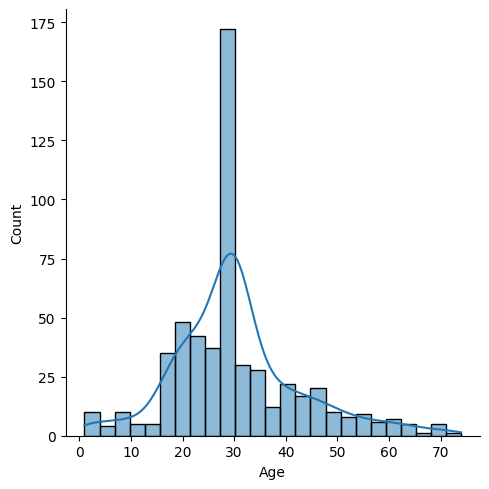

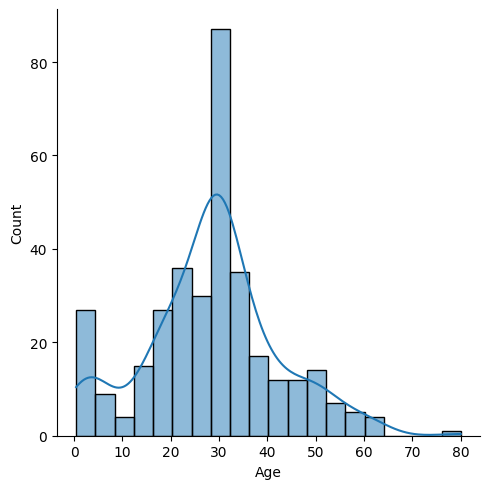

In [73]:
sns.displot(train['Age'][train['Survived']==0],kde=True)
sns.displot(train['Age'][train['Survived']==1],kde=True)

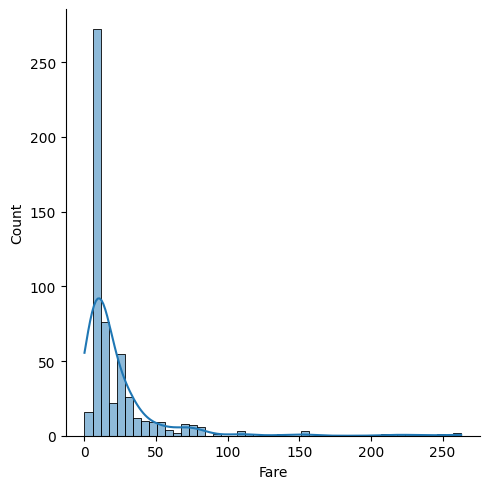

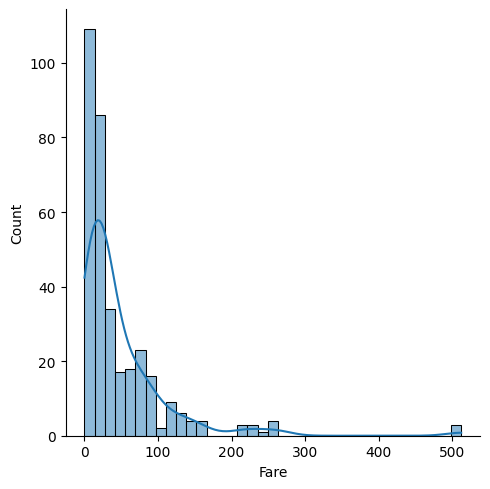

In [74]:
sns.displot(train['Fare'][train['Survived']==0],kde=True)
sns.displot(train['Fare'][train['Survived']==1],kde=True)

In [75]:
train.drop(columns=['Ticket'],inplace=True)
test.drop(columns=['Ticket'],inplace=True)

In [76]:
train['family_size']=train['SibSp']+train['Parch']+1

In [78]:
train['family_size'].value_counts()

family_size
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64